In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

In [2]:
x = np.linspace(0, 20, 5000)

a_C = 0.5

h_C = [0.2, 0.5] #h[0] = h<((a+1)**2)/4, h[1] = h = ((a+1)**2)/4, h[2] = h>((a+1)**2)/4

In [3]:
def Plot(
        x,
        f, 
        x_0,
        f_x_0,
        fig_label = "fig_label"
        ):
    
    plt.figure()
    plt.plot(x, f, label = fig_label)
    plt.scatter(x_0, f_x_0, label = fig_label)

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.xlim(0, 5)
    plt.ylim(-10, 10)

    plt.grid()
    plt.legend(loc = "upper left")
    plt.show()

In [4]:
def Function(x, a, h):
    f_x = x*(1-x) - h*(x/(a+x))

    df_0 = 1 - (h/a)

    return f_x, df_0

In [5]:
def find_zero_indices(x, f_x, tol=1e-6):
    # 1. 부호 변화로 찾는 근
    sign_change_idx = np.where(f_x[:-1] * f_x[1:] < 0)[0]

    # 2. |f|가 작은 점
    near_zero_idx = np.where(np.abs(f_x) < tol)[0]

    # 3. 중근 후보: |f|가 작고, 국소 extremum인 점
    #    f'(x) 부호가 바뀌는 곳을 이용
    df = np.diff(f_x)
    extremum_idx = np.where(df[:-1] * df[1:] < 0)[0] + 1

    double_root_idx = np.array(
        [i for i in extremum_idx if np.abs(f_x[i]) < tol],
        dtype=int
    )

    # 4. 전부 합치기
    idx_all = np.unique(np.concatenate([sign_change_idx, near_zero_idx, double_root_idx]))

    return idx_all

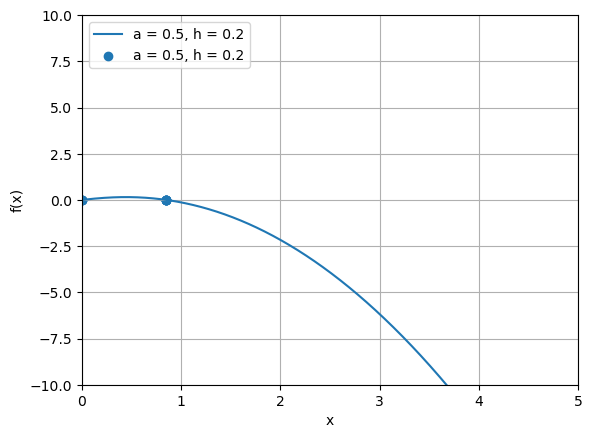

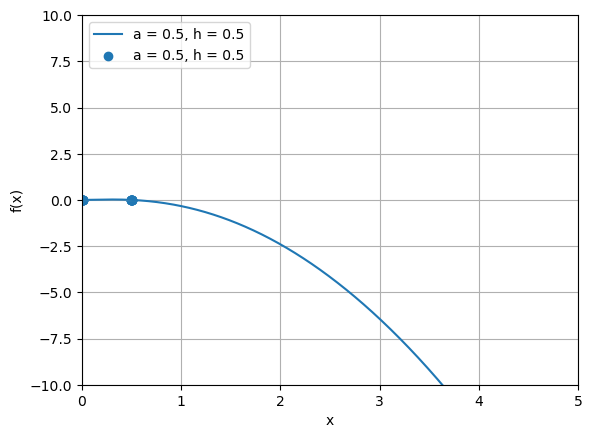

In [6]:
for i in range(len(h_C)):

        f_x, _ = Function(x, a_C, h_C[i])

        x_zeros = []
        f_x_zeros = []
        idx = find_zero_indices(x, f_x, tol=1e-4)

        if len(idx) != 0:
            for j in idx:
                x_zeros.append(x[idx])
                f_x_zeros.append(f_x[idx])

        else:
            pass

        Plot(x, f_x, x_zeros, f_x_zeros, f"a = {a_C}, h = {h_C[i]}")

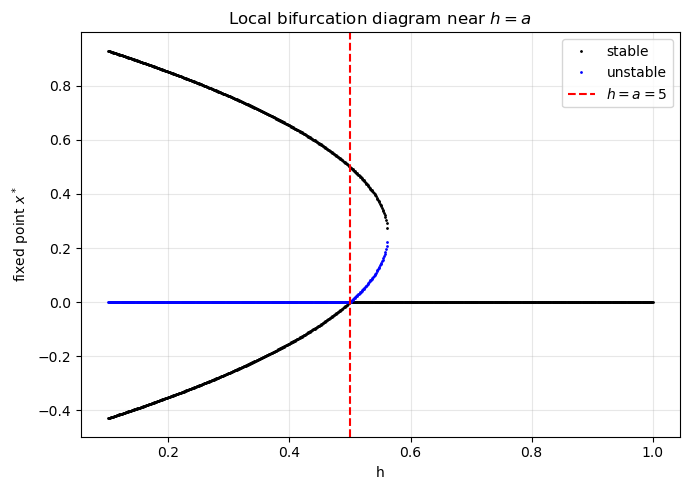

In [7]:
a = 0.5
h_vals = np.linspace(0.1, 1, 800)   # h=a=5 근처만 확대

def fprime(x, a, h):
    return 1 - 2*x - h*a/(a+x)**2

h_stable = []
x_stable = []

h_unstable = []
x_unstable = []

for h in h_vals:
    # 항상 존재하는 branch x=0
    slope0 = fprime(0.0, a, h)
    if slope0 < 0:
        h_stable.append(h)
        x_stable.append(0.0)
    else:
        h_unstable.append(h)
        x_unstable.append(0.0)

    # 다른 branch: x^2 + (a-1)x + (h-a) = 0
    D = (a+1)**2 - 4*h
    if D >= 0:
        s = np.sqrt(D)
        x1 = (1-a + s)/2
        x2 = (1-a - s)/2

        for x_star in [x1, x2]:
            # D번에서는 x=0 근처 branch만 보는 게 좋음
            if -1.5 <= x_star <= 1.5:
                slope = fprime(x_star, a, h)
                if slope < 0:
                    h_stable.append(h)
                    x_stable.append(x_star)
                else:
                    h_unstable.append(h)
                    x_unstable.append(x_star)

plt.figure(figsize=(7,5))

plt.plot(h_stable, x_stable, 'k.', ms=2, label='stable')
plt.plot(h_unstable, x_unstable, 'b.', ms=2, mfc='white', label='unstable')

plt.axvline(a, color='red', linestyle='--', linewidth=1.5, label=r'$h=a=5$')

plt.xlabel("h")
plt.ylabel(r'fixed point $x^*$')
plt.title(r'Local bifurcation diagram near $h=a$')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

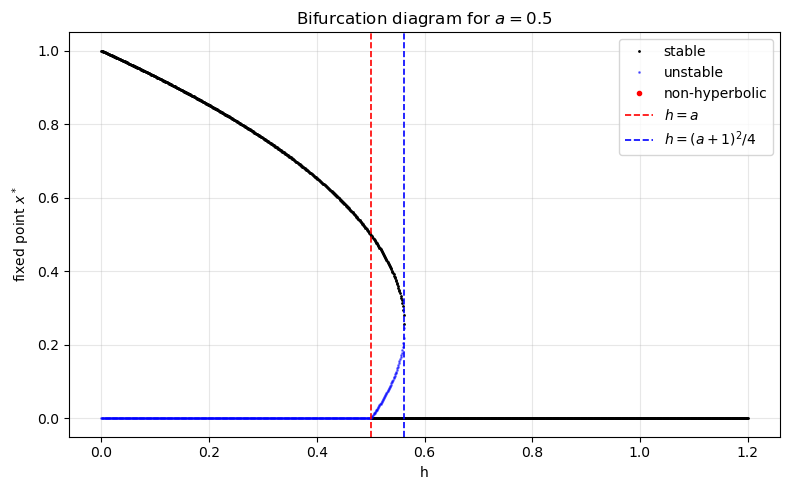

In [8]:
import numpy as np
import matplotlib.pyplot as plt

a = 0.5
h_vals = np.linspace(0.0, 1.2, 1200)

def fprime(x, a, h):
    return 1 - 2*x - h*a/(a+x)**2

h_stable = []
x_stable = []

h_unstable = []
x_unstable = []

h_semi = []
x_semi = []

for h in h_vals:
    # -------------------------------------------------
    # 1. 항상 존재하는 고정점 x = 0
    # -------------------------------------------------
    slope0 = fprime(0.0, a, h)

    if np.isclose(slope0, 0.0, atol=1e-10):
        h_semi.append(h)
        x_semi.append(0.0)
    elif slope0 < 0:
        h_stable.append(h)
        x_stable.append(0.0)
    else:
        h_unstable.append(h)
        x_unstable.append(0.0)

    # -------------------------------------------------
    # 2. 비영점 고정점의 해 존재 조건
    #    x^2 - (1-a)x + (h-a) = 0
    #    D = (a+1)^2 - 4h >= 0 이어야 실근 존재
    # -------------------------------------------------
    D = (a + 1)**2 - 4*h

    if D < 0:
        continue

    s = np.sqrt(D)
    x_plus  = (1 - a + s) / 2
    x_minus = (1 - a - s) / 2

    # -------------------------------------------------
    # 3. 물리적으로 의미 있는 해만 선택: x* >= 0
    # -------------------------------------------------
    roots = [x_minus, x_plus]

    # 중근 방지
    physical_roots = []
    for r in roots:
        if r >= 0:
            if not any(np.isclose(r, rr, atol=1e-10) for rr in physical_roots):
                physical_roots.append(r)

    # -------------------------------------------------
    # 4. 각 해의 안정성 판별
    # -------------------------------------------------
    for x_star in physical_roots:
        slope = fprime(x_star, a, h)

        if np.isclose(slope, 0.0, atol=1e-10):
            h_semi.append(h)
            x_semi.append(x_star)
        elif slope < 0:
            h_stable.append(h)
            x_stable.append(x_star)
        else:
            h_unstable.append(h)
            x_unstable.append(x_star)

# -------------------------------------------------
# 5. 그래프
# -------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(h_stable, x_stable, 'k.', ms=2, label='stable')
plt.plot(h_unstable, x_unstable, 'b.', ms=2, alpha=0.5, label='unstable')
plt.plot(h_semi, x_semi, 'ro', ms=3, label='non-hyperbolic')

plt.axvline(a, color='red', linestyle='--', linewidth=1.2, label=r'$h=a$')
plt.axvline((a+1)**2/4, color='blue', linestyle='--', linewidth=1.2,
            label=r'$h=(a+1)^2/4$')

plt.xlabel("h")
plt.ylabel(r'fixed point $x^*$')
plt.title(fr'Bifurcation diagram for $a={a}$')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

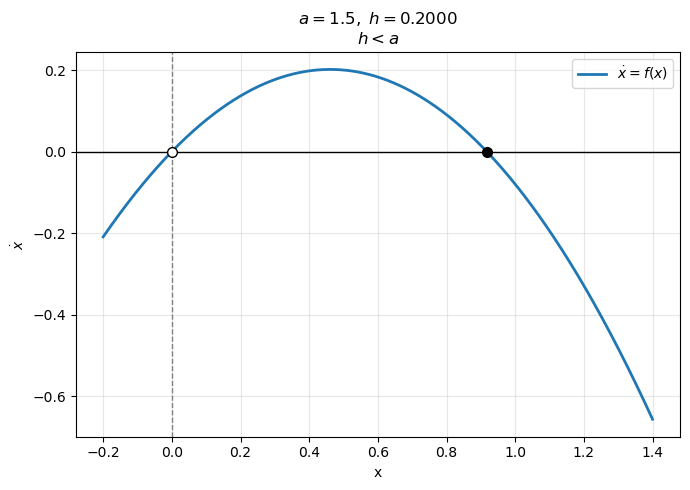

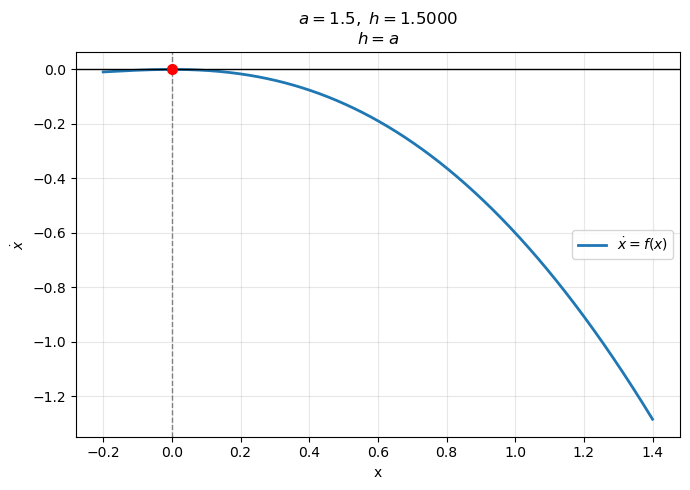

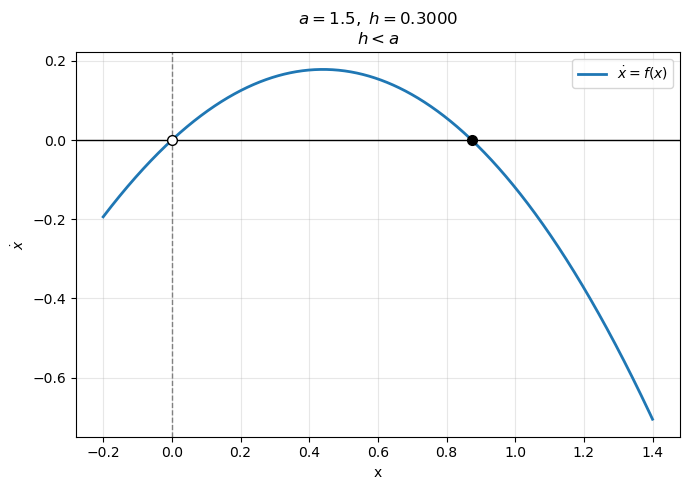

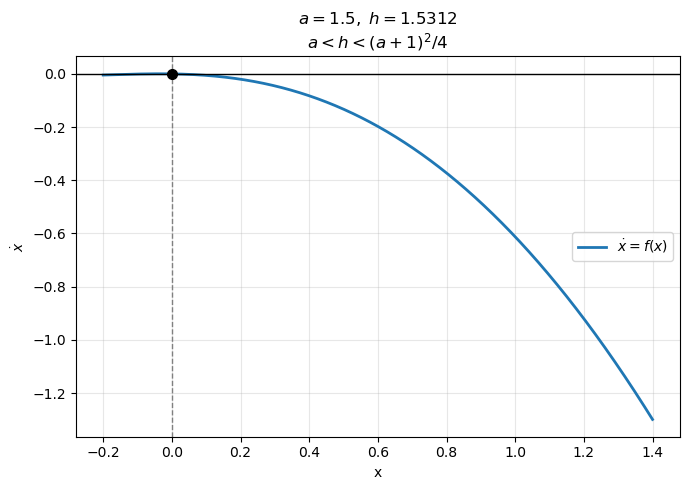

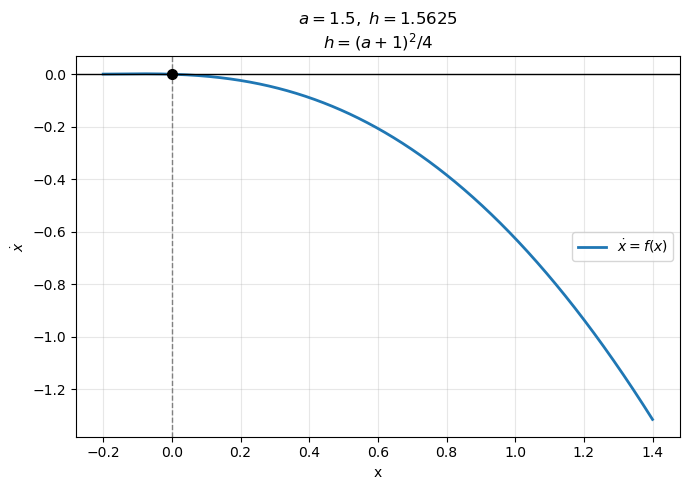

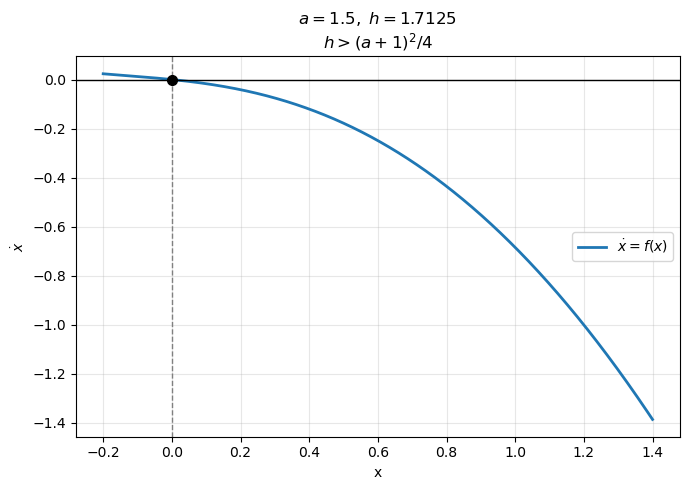

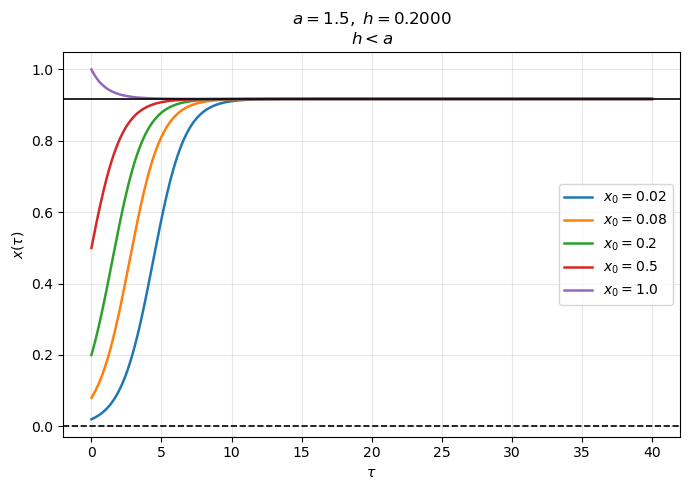

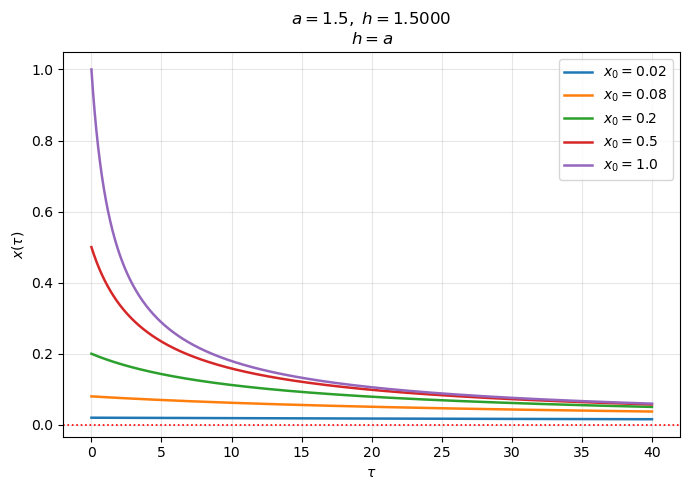

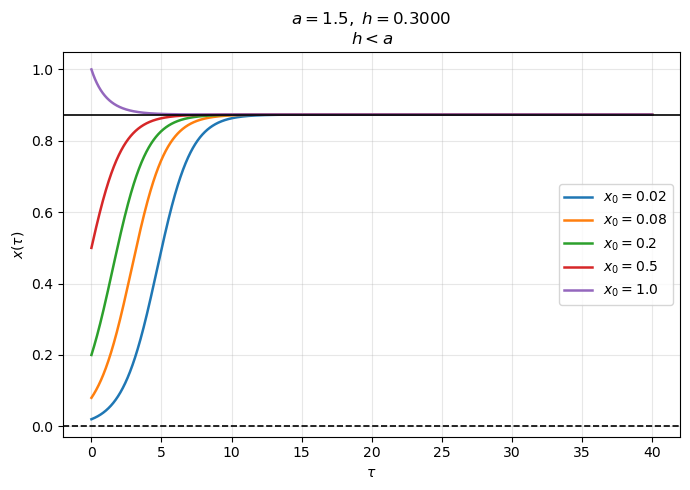

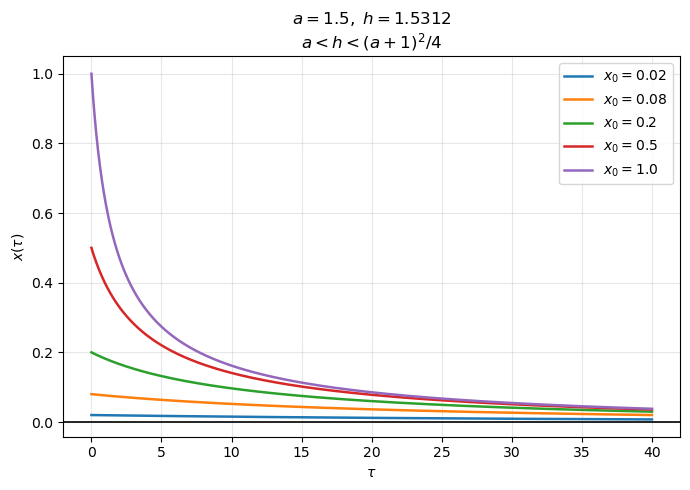

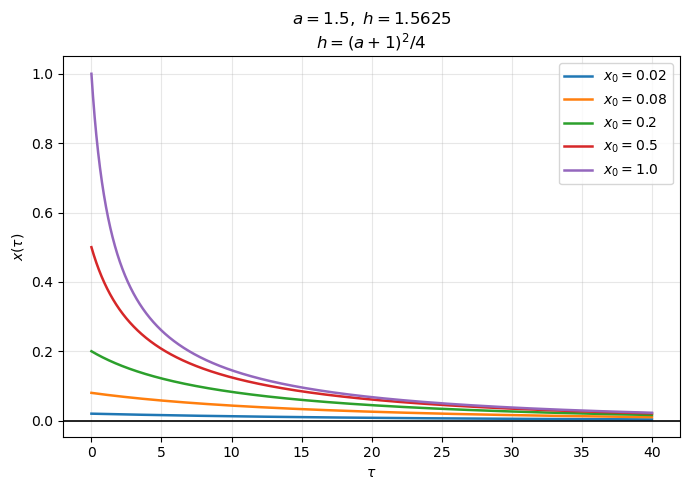

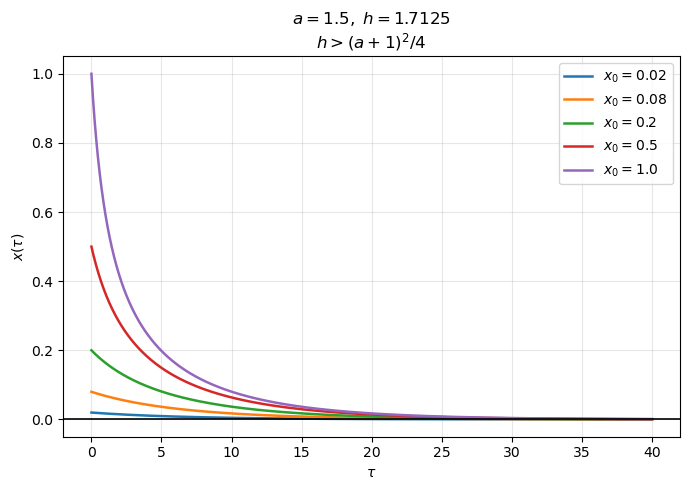

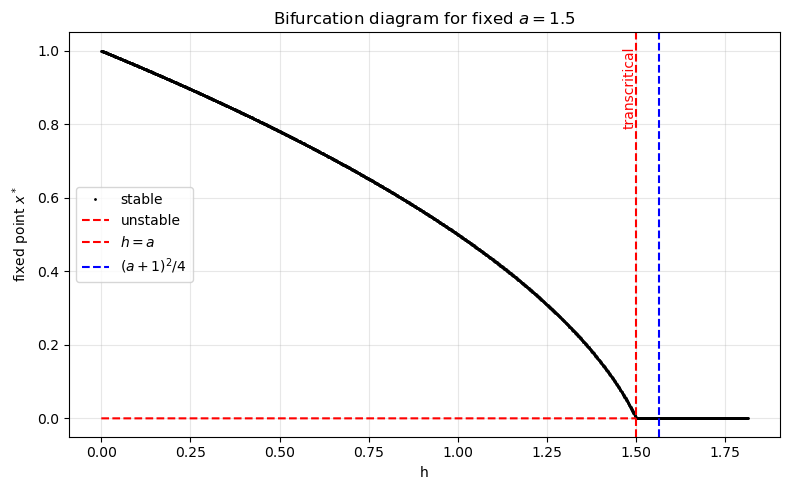

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 기본 함수
# =========================================================
def Function(x, a, h):
    f_x = x*(1 - x) - h*(x/(a + x))
    df_0 = 1 - (h/a)
    return f_x, df_0

def f_scalar(x, a, h):
    return x*(1 - x) - h*(x/(a + x))

def fprime(x, a, h):
    return 1 - 2*x - (h*a)/(a + x)**2


# =========================================================
# 고정점 계산
# x = 0, 그리고 x^2 - (1-a)x + (h-a)=0
# 물리적으로 의미 있는 x>=0만 사용
# =========================================================
def fixed_points(a, h, tol=1e-10):
    roots = [0.0]

    D = (a + 1)**2 - 4*h
    if D >= -tol:
        D = max(D, 0.0)
        s = np.sqrt(D)

        x_plus  = (1 - a + s)/2
        x_minus = (1 - a - s)/2

        for r in [x_minus, x_plus]:
            if r >= -tol:
                r = 0.0 if abs(r) < tol else r
                if not any(np.isclose(r, rr, atol=tol) for rr in roots):
                    roots.append(r)

    roots.sort()
    return roots


# =========================================================
# 안정성 판정
# =========================================================
def stability(x_star, a, h, tol=1e-10):
    slope = fprime(x_star, a, h)
    if slope < -tol:
        return "stable"
    elif slope > tol:
        return "unstable"
    else:
        return "nonhyperbolic"


# =========================================================
# 경우 분류
# d번 해석 기준으로 h=a에서 bifurcation
# 그리고 전체적으로는 h=(a+1)^2/4 도 표시
# =========================================================
def classify_case(a, h, tol=1e-10):
    h_tc = a
    h_sn = (a + 1)**2 / 4

    if np.isclose(h, h_tc, atol=tol):
        return r"$h=a$"
    elif np.isclose(h, h_sn, atol=tol):
        return r"$h=(a+1)^2/4$"
    elif h < h_tc:
        return r"$h<a$"
    elif h_tc < h < h_sn:
        return r"$a<h<(a+1)^2/4$"
    else:
        return r"$h>(a+1)^2/4$"


# =========================================================
# Euler로 x(tau) 적분
# =========================================================
def simulate_x(a, h, x0, tau_max=40, dt=0.01):
    n = int(tau_max/dt) + 1
    tau = np.linspace(0, tau_max, n)
    x = np.zeros(n)
    x[0] = x0

    for i in range(n - 1):
        x[i+1] = x[i] + dt * f_scalar(x[i], a, h)
        # 필요시 음수 방지
        if x[i+1] < -1:
            x[i+1] = -1

    return tau, x


# =========================================================
# 1. 각 경우에 대해 xdot-x 그래프
# =========================================================
def Plot_xdot_vs_x(a, h_list, x_min=-0.2, x_max=1.5, n_x=2000):
    x = np.linspace(x_min, x_max, n_x)

    for h in h_list:
        f_x, df_0 = Function(x, a, h)
        roots = fixed_points(a, h)

        plt.figure(figsize=(7, 5))
        plt.plot(x, f_x, linewidth=2, label=fr"$\dot x=f(x)$")
        plt.axhline(0, color='k', linewidth=1)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)

        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                plt.plot(r, 0, 'ko', ms=7)
            elif st == "unstable":
                plt.plot(r, 0, 'wo', mec='k', ms=7)
            else:
                plt.plot(r, 0, 'ro', ms=7)

        plt.xlabel("x")
        plt.ylabel(r"$\dot{x}$")
        plt.title(fr"$a={a},\; h={h:.4f}$" + "\n" + classify_case(a, h))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================================================
# 2. 각 경우에 대해 x(tau)-tau 그래프
# 여러 초기조건에서 어떻게 가는지 확인
# =========================================================
def Plot_x_vs_tau(a, h_list, x0_list=None, tau_max=40, dt=0.01):
    if x0_list is None:
        x0_list = [0.02, 0.1, 0.3, 0.7, 1.1]

    for h in h_list:
        plt.figure(figsize=(7, 5))

        for x0 in x0_list:
            tau, x = simulate_x(a, h, x0, tau_max=tau_max, dt=dt)
            plt.plot(tau, x, linewidth=1.8, label=fr"$x_0={x0}$")

        roots = fixed_points(a, h)
        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                plt.axhline(r, color='k', linestyle='-', linewidth=1.2)
            elif st == "unstable":
                plt.axhline(r, color='k', linestyle='--', linewidth=1.2)
            else:
                plt.axhline(r, color='r', linestyle=':', linewidth=1.2)

        plt.xlabel(r"$\tau$")
        plt.ylabel(r"$x(\tau)$")
        plt.title(fr"$a={a},\; h={h:.4f}$" + "\n" + classify_case(a, h))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================================================
# 3. bifurcation diagram: x*-h
# stable / unstable / nonhyperbolic 표시
# h=a에서 transcritical bifurcation 표시
# =========================================================
def Plot_bifurcation(a, h_min=0.0, h_max=1.2, n_h=1600):
    h_vals = np.linspace(h_min, h_max, n_h)

    h_stable = []
    x_stable = []

    h_unstable = []
    x_unstable = []

    h_non = []
    x_non = []

    for h in h_vals:
        roots = fixed_points(a, h)

        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                h_stable.append(h)
                x_stable.append(r)
            elif st == "unstable":
                h_unstable.append(h)
                x_unstable.append(r)
            else:
                h_non.append(h)
                x_non.append(r)

    plt.figure(figsize=(8, 5))

    plt.plot(h_stable, x_stable, 'k.', ms=2, label='stable')
    plt.plot(h_unstable, x_unstable, 'r--', mec='k', ms=2, label='unstable')
    if len(h_non) > 0:
        plt.plot(h_non, x_non, 'ro', ms=4, label='nonhyperbolic')

    h_tc = a
    h_sn = (a + 1)**2 / 4

    plt.axvline(h_tc, color='red', linestyle='--', linewidth=1.5, label=r'$h=a$')
    plt.axvline(h_sn, color='blue', linestyle='--', linewidth=1.5, label=r'$(a+1)^2/4$')

    plt.text(h_tc, 0.9, 'transcritical', color='red', rotation=90,
             ha='right', va='center')

    plt.xlabel("h")
    plt.ylabel(r"fixed point $x^*$")
    plt.title(fr"Bifurcation diagram for fixed $a={a}$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 4. 실행
# a를 고정하고 h를 경우별로 선택
# =========================================================
a_C = 1.5

h_tc = a_C
h_sn = (a_C + 1)**2 / 4

# 경우별 대표값
h_C = [
    0.2,                 # h < a
    h_tc,                # h = a
    0.3,                 # h < a 인 다른 예시 원하면 유지/삭제 가능
    (h_tc + h_sn)/2,     # a < h < (a+1)^2/4
    h_sn,                # h = (a+1)^2/4
    h_sn + 0.15          # h > (a+1)^2/4
]

# 중복 제거
h_C_clean = []
for h in h_C:
    if not any(np.isclose(h, hh, atol=1e-10) for hh in h_C_clean):
        h_C_clean.append(h)

# 1) xdot-x 그래프
Plot_xdot_vs_x(a_C, h_C_clean, x_min=-0.2, x_max=1.4)

# 2) x-tau 그래프
Plot_x_vs_tau(a_C, h_C_clean, x0_list=[0.02, 0.08, 0.2, 0.5, 1.0], tau_max=40, dt=0.01)

# 3) bifurcation diagram
Plot_bifurcation(a_C, h_min=0.0, h_max=max(1.2, h_sn + 0.25), n_h=1800)

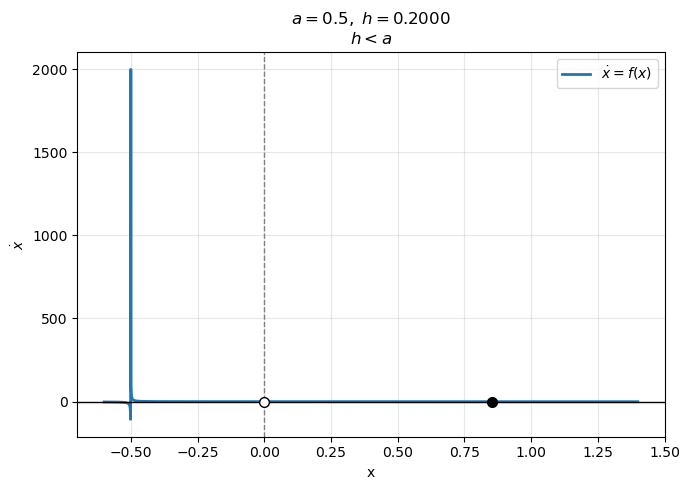

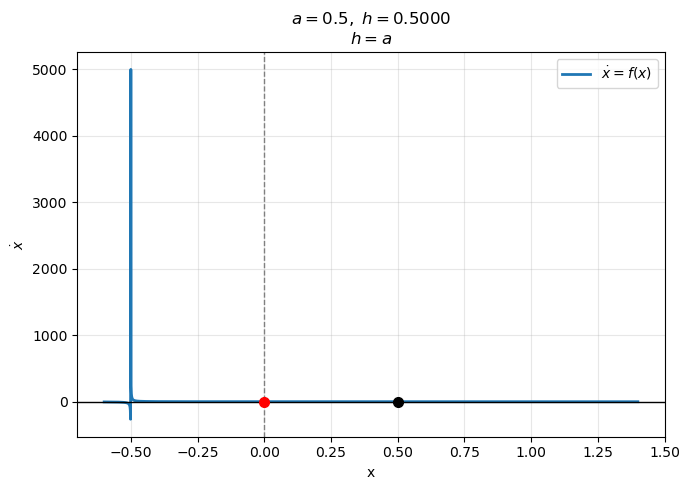

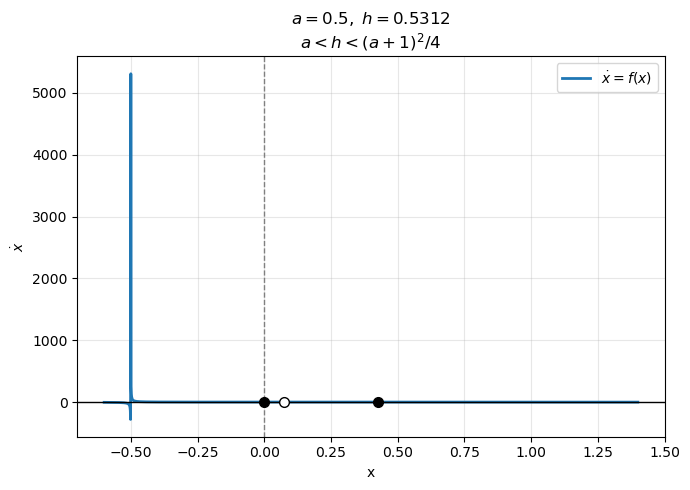

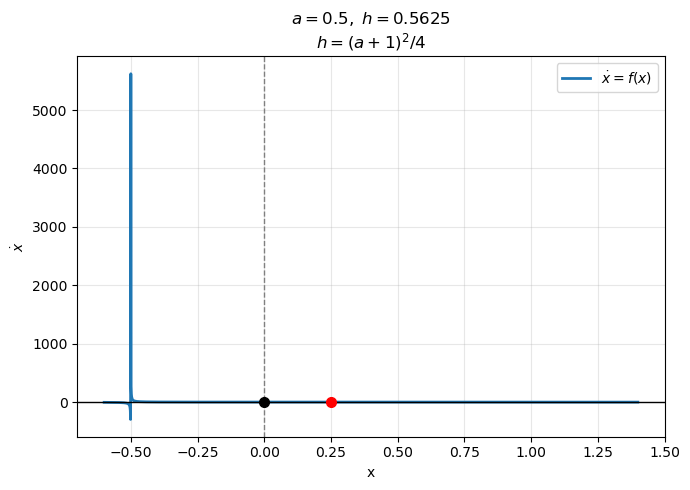

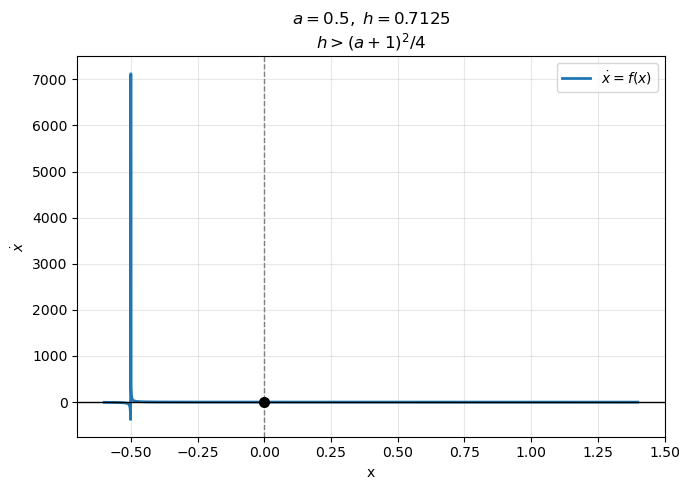

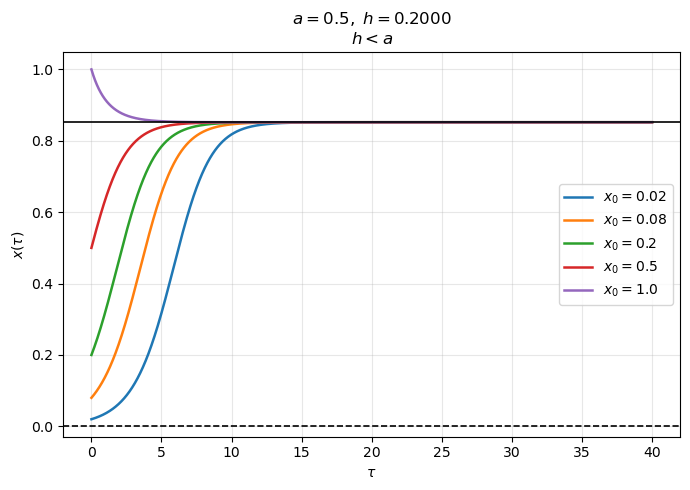

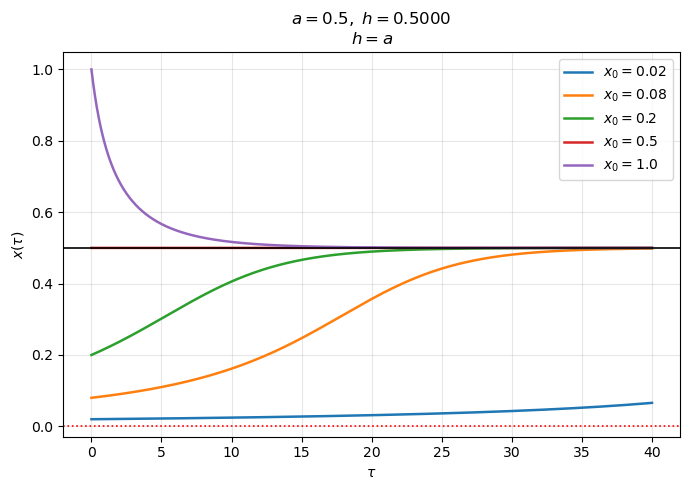

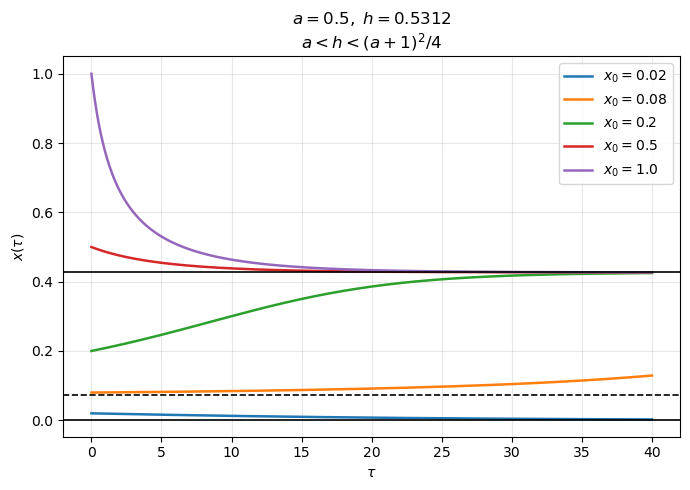

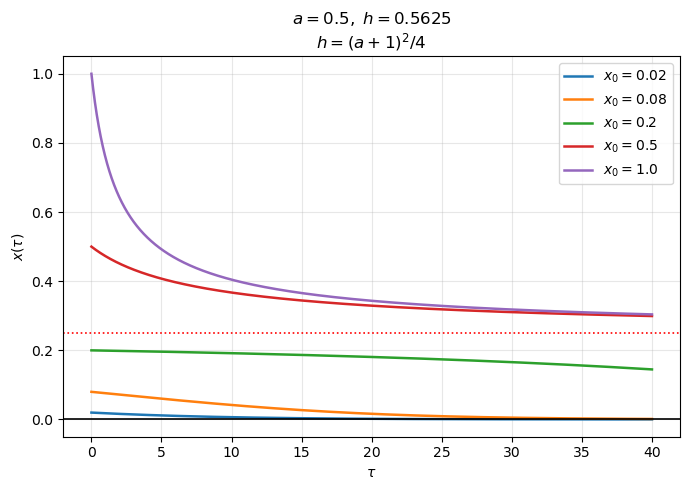

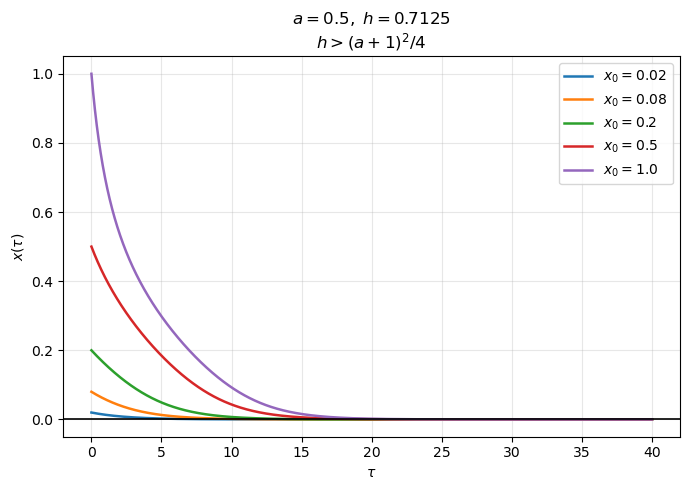

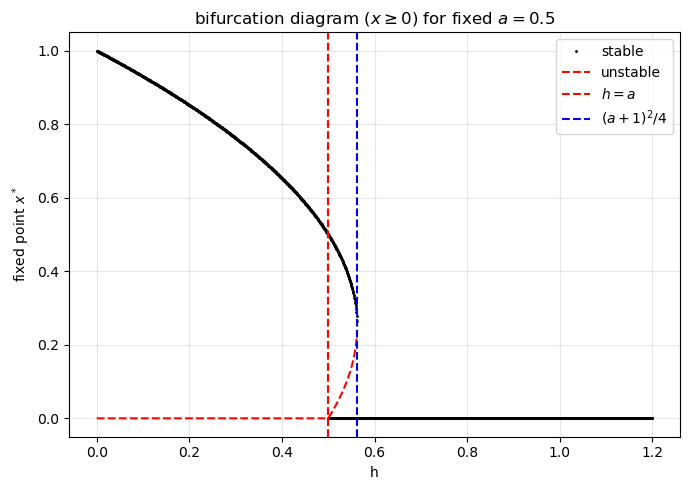

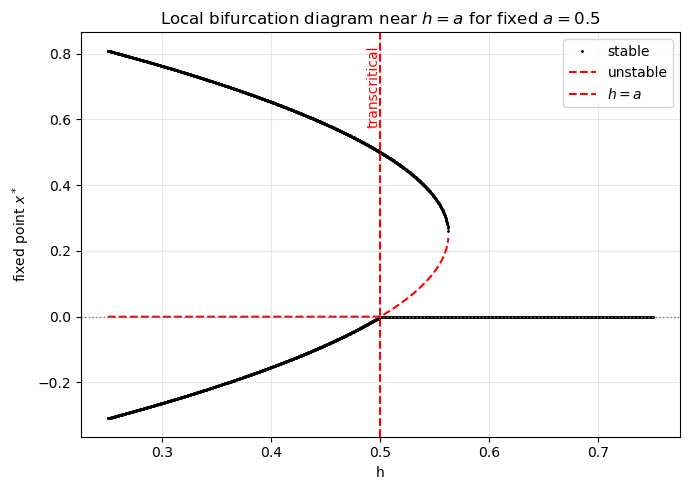

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 기본 함수
# =========================================================
def Function(x, a, h):
    f_x = x*(1 - x) - h*(x/(a + x))
    df_0 = 1 - (h/a)
    return f_x, df_0

def f_scalar(x, a, h):
    return x*(1 - x) - h*(x/(a + x))

def fprime(x, a, h):
    return 1 - 2*x - (h*a)/(a + x)**2


# =========================================================
# 고정점 계산
# x = 0, 그리고 x^2 - (1-a)x + (h-a)=0
# physical_only=True 이면 x>=0만 사용
# =========================================================
def fixed_points(a, h, physical_only=True, tol=1e-10):
    roots = [0.0]

    D = (a + 1)**2 - 4*h
    if D >= -tol:
        D = max(D, 0.0)
        s = np.sqrt(D)

        x_plus  = (1 - a + s)/2
        x_minus = (1 - a - s)/2

        for r in [x_minus, x_plus]:
            if not any(np.isclose(r, rr, atol=tol) for rr in roots):
                roots.append(r)

    roots.sort()

    if physical_only:
        roots = [r for r in roots if r >= -tol]
        roots = [0.0 if abs(r) < tol else r for r in roots]

    return roots


# =========================================================
# 안정성 판정
# =========================================================
def stability(x_star, a, h, tol=1e-10):
    slope = fprime(x_star, a, h)
    if slope < -tol:
        return "stable"
    elif slope > tol:
        return "unstable"
    else:
        return "nonhyperbolic"


# =========================================================
# 경우 분류
# =========================================================
def classify_case(a, h, tol=1e-10):
    h_tc = a
    h_sn = (a + 1)**2 / 4

    if np.isclose(h, h_tc, atol=tol):
        return r"$h=a$"
    elif np.isclose(h, h_sn, atol=tol):
        return r"$h=(a+1)^2/4$"
    elif h < h_tc:
        return r"$h<a$"
    elif h_tc < h < h_sn:
        return r"$a<h<(a+1)^2/4$"
    else:
        return r"$h>(a+1)^2/4$"


# =========================================================
# Euler로 x(tau) 적분
# =========================================================
def simulate_x(a, h, x0, tau_max=40, dt=0.01):
    n = int(tau_max/dt) + 1
    tau = np.linspace(0, tau_max, n)
    x = np.zeros(n)
    x[0] = x0

    for i in range(n - 1):
        x[i+1] = x[i] + dt * f_scalar(x[i], a, h)

    return tau, x


# =========================================================
# 1. 각 경우에 대해 xdot-x 그래프
# 물리적 해만 표시
# =========================================================
def Plot_xdot_vs_x(a, h_list, x_min=-0.4, x_max=1.5, n_x=2000):
    x = np.linspace(x_min, x_max, n_x)

    for h in h_list:
        f_x, _ = Function(x, a, h)
        roots = fixed_points(a, h, physical_only=True)

        plt.figure(figsize=(7, 5))
        plt.plot(x, f_x, linewidth=2, label=fr"$\dot x=f(x)$")
        plt.axhline(0, color='k', linewidth=1)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)

        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                plt.plot(r, 0, 'ko', ms=7)
            elif st == "unstable":
                plt.plot(r, 0, 'wo', mec='k', ms=7)
            else:
                plt.plot(r, 0, 'ro', ms=7)

        plt.xlabel("x")
        plt.ylabel(r"$\dot{x}$")
        plt.title(fr"$a={a},\; h={h:.4f}$" + "\n" + classify_case(a, h))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================================================
# 2. 각 경우에 대해 x(tau)-tau 그래프
# =========================================================
def Plot_x_vs_tau(a, h_list, x0_list=None, tau_max=40, dt=0.01):
    if x0_list is None:
        x0_list = [0.02, 0.1, 0.3, 0.7, 1.1]

    for h in h_list:
        plt.figure(figsize=(7, 5))

        for x0 in x0_list:
            tau, x = simulate_x(a, h, x0, tau_max=tau_max, dt=dt)
            plt.plot(tau, x, linewidth=1.8, label=fr"$x_0={x0}$")

        roots = fixed_points(a, h, physical_only=True)
        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                plt.axhline(r, color='k', linestyle='-', linewidth=1.2)
            elif st == "unstable":
                plt.axhline(r, color='k', linestyle='--', linewidth=1.2)
            else:
                plt.axhline(r, color='r', linestyle=':', linewidth=1.2)

        plt.xlabel(r"$\tau$")
        plt.ylabel(r"$x(\tau)$")
        plt.title(fr"$a={a},\; h={h:.4f}$" + "\n" + classify_case(a, h))
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================================================
# 3. 물리적 bifurcation diagram: x>=0만 그림
# 여기서는 transcritical 글자를 넣지 않음
# =========================================================
def Plot_bifurcation_physical(a, h_min=0.0, h_max=1.2, n_h=1600):
    h_vals = np.linspace(h_min, h_max, n_h)

    h_stable = []
    x_stable = []

    h_unstable = []
    x_unstable = []

    h_non = []
    x_non = []

    for h in h_vals:
        roots = fixed_points(a, h, physical_only=True)

        for r in roots:
            st = stability(r, a, h)
            if st == "stable":
                h_stable.append(h)
                x_stable.append(r)
            elif st == "unstable":
                h_unstable.append(h)
                x_unstable.append(r)
            else:
                h_non.append(h)
                x_non.append(r)

    plt.figure(figsize=(7, 5))

    plt.plot(h_stable, x_stable, 'k.', ms=2, label='stable')
    plt.plot(h_unstable, x_unstable, 'r--', linewidth=1.5, label='unstable')
    if len(h_non) > 0:
        plt.plot(h_non, x_non, 'ro', ms=4, label='nonhyperbolic')

    h_tc = a
    h_sn = (a + 1)**2 / 4

    plt.axvline(h_tc, color='red', linestyle='--', linewidth=1.5, label=r'$h=a$')
    plt.axvline(h_sn, color='blue', linestyle='--', linewidth=1.5, label=r'$(a+1)^2/4$')

    plt.xlabel("h")
    plt.ylabel(r"fixed point $x^*$")
    plt.title(fr"bifurcation diagram ($x\geq 0$) for fixed $a={a}$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 4. d번 전용 local bifurcation diagram
# x<0까지 포함해서 h=a에서 transcritical을 직접 그림
# =========================================================
def Plot_bifurcation_local_d(a, h_width=0.25, n_h=1600):
    h_tc = a
    h_min = h_tc - h_width
    h_max = h_tc + h_width
    h_vals = np.linspace(h_min, h_max, n_h)

    h_stable = []
    x_stable = []

    h_unstable = []
    x_unstable = []

    h_non = []
    x_non = []

    for h in h_vals:
        roots = fixed_points(a, h, physical_only=False)

        # d번은 x=0 근처의 local bifurcation을 보는 것이므로
        # x=0 근처 해만 표시
        for r in roots:
            if -1.0 <= r <= 1.0:
                st = stability(r, a, h)
                if st == "stable":
                    h_stable.append(h)
                    x_stable.append(r)
                elif st == "unstable":
                    h_unstable.append(h)
                    x_unstable.append(r)
                else:
                    h_non.append(h)
                    x_non.append(r)

    plt.figure(figsize=(7, 5))

    plt.plot(h_stable, x_stable, 'k.', ms=2, label='stable')
    plt.plot(h_unstable, x_unstable, 'r--', linewidth=1.5, label='unstable')
    if len(h_non) > 0:
        plt.plot(h_non, x_non, 'ro', ms=4, label='nonhyperbolic')

    plt.axvline(h_tc, color='red', linestyle='--', linewidth=1.5, label=r'$h=a$')
    plt.axhline(0, color='gray', linestyle=':', linewidth=1)

    plt.text(h_tc, 0.7, 'transcritical', color='red', rotation=90,
             ha='right', va='center')

    plt.xlabel("h")
    plt.ylabel(r"fixed point $x^*$")
    plt.title(fr"Local bifurcation diagram near $h=a$ for fixed $a={a}$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 5. 실행
# =========================================================
a_C = 0.5

h_tc = a_C
h_sn = (a_C + 1)**2 / 4

h_C = [
    0.2,
    h_tc,
    (h_tc + h_sn)/2,
    h_sn,
    h_sn + 0.15
]

h_C_clean = []
for h in h_C:
    if not any(np.isclose(h, hh, atol=1e-10) for hh in h_C_clean):
        h_C_clean.append(h)

# 1) xdot-x 그래프
Plot_xdot_vs_x(a_C, h_C_clean, x_min=-0.6, x_max=1.4)

# 2) x-tau 그래프
Plot_x_vs_tau(a_C, h_C_clean, x0_list=[0.02, 0.08, 0.2, 0.5, 1.0], tau_max=40, dt=0.01)

# 3) 물리적 bifurcation diagram
Plot_bifurcation_physical(a_C, h_min=0.0, h_max=max(1.2, h_sn + 0.25), n_h=1800)

# 4) d번 전용 local bifurcation diagram
Plot_bifurcation_local_d(a_C, h_width=0.25, n_h=1800)

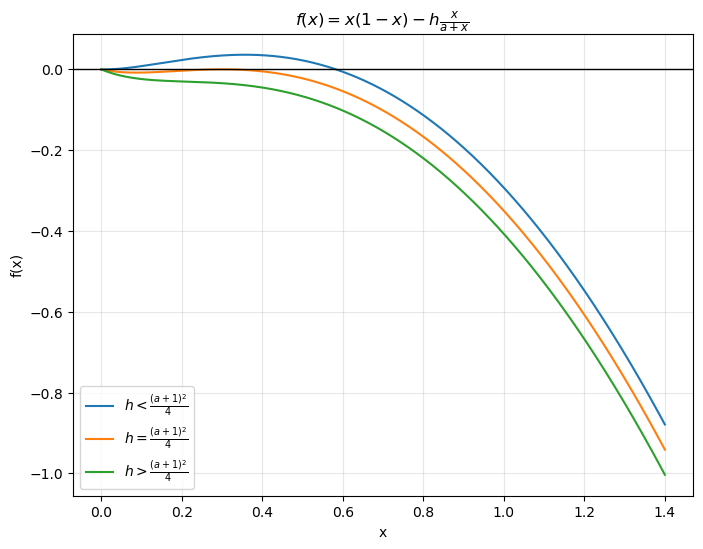

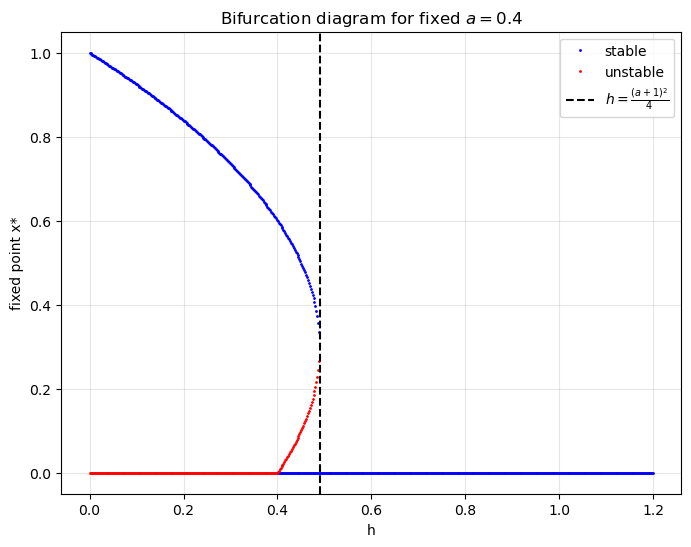

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 함수 정의
# -----------------------------
def f(x, a, h):
    return x * (1 - x) - h * x / (a + x)

def x_branches(a, h):
    """
    x=0 이외의 고정점:
    x^2 + (a-1)x + (h-a) = 0
    """
    D = (a + 1)**2 - 4*h
    if D < 0:
        return []
    elif np.isclose(D, 0):
        return [(1 - a) / 2]
    else:
        sqrtD = np.sqrt(D)
        x1 = (1 - a - sqrtD) / 2
        x2 = (1 - a + sqrtD) / 2
        return [x1, x2]

def fp_stability(x, a, h, eps=1e-10):
    """
    고정점 안정성 판별: f'(x) < 0 stable, > 0 unstable
    """
    df = 1 - 2*x - h * a / (a + x)**2
    if df < -eps:
        return "stable"
    elif df > eps:
        return "unstable"
    else:
        return "neutral"

# -----------------------------
# 1) saddle-node 근처의 f(x) 그래프
# -----------------------------
a = 0.4
h_c = (a + 1)**2 / 4

h_values = [h_c - 0.08, h_c, h_c + 0.08]
labels = [
    r"$h < \frac{(a+1)^2}{4}$",
    r"$h = \frac{(a+1)^2}{4}$",
    r"$h > \frac{(a+1)^2}{4}$"
]
x = np.linspace(0, 1.4, 1000)

plt.figure(figsize=(8, 6))
for h, label in zip(h_values, labels):
    plt.plot(x, f(x, a, h), label=label)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(rf"$f(x)=x(1-x)-h\frac{{x}}{{a+x}}$ ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 2) bifurcation diagram in (h, x)
#    a를 고정하고 x=0 및 비영점 고정점 표시
# -----------------------------
h_arr = np.linspace(0, 1.2, 600)

stable_h = []
stable_x = []
unstable_h = []
unstable_x = []

for h in h_arr:
    # x=0
    x0 = 0.0
    st0 = fp_stability(x0, a, h)
    if st0 == "stable":
        stable_h.append(h)
        stable_x.append(x0)
    else:
        unstable_h.append(h)
        unstable_x.append(x0)

    # 비영점 고정점들
    roots = x_branches(a, h)
    for xr in roots:
        if xr >= 0:  # 생물학적으로 의미 있는 영역만
            st = fp_stability(xr, a, h)
            if st == "stable":
                stable_h.append(h)
                stable_x.append(xr)
            else:
                unstable_h.append(h)
                unstable_x.append(xr)

plt.figure(figsize=(8, 6))
plt.plot(stable_h, stable_x, 'b.', markersize=2, label="stable")
plt.plot(unstable_h, unstable_x, 'r.', markersize=2, label="unstable")
plt.axvline(h_c, color='k', linestyle='--', label=r"$h = \frac{(a+1)^2}{4}$")
plt.xlabel("h")
plt.ylabel("fixed point x*")
plt.title(rf"Bifurcation diagram for fixed $a={a}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

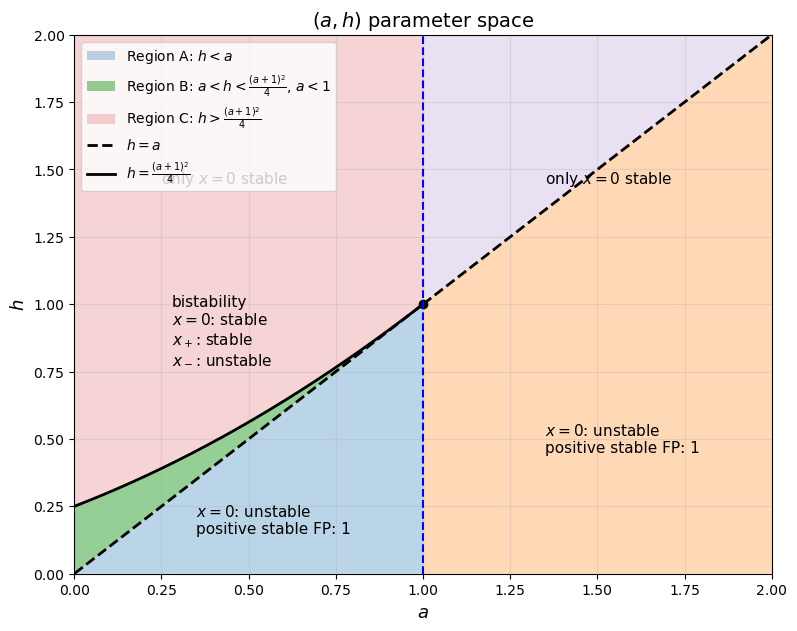

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 경계 곡선
# -----------------------------
a1 = np.linspace(0.001, 1.0, 500)
a2 = np.linspace(1.0, 2.0, 500)

h_line_1 = a1                     # h = a   (0 < a < 1)
h_line_2 = (a1 + 1)**2 / 4       # h = (a+1)^2 / 4   (0 < a < 1)
h_line_3 = a2                     # h = a   (a > 1)

# -----------------------------
# stability region 색칠용 영역
# -----------------------------
a_fill_left = np.linspace(0.001, 1.0, 500)
a_fill_right = np.linspace(1.0, 2.0, 500)

h_lower_left = a_fill_left
h_upper_left = (a_fill_left + 1)**2 / 4

# -----------------------------
# 그림
# -----------------------------
plt.figure(figsize=(9, 7))

# Region A: h < a
plt.fill_between(
    a_fill_left, 0, h_lower_left,
    alpha=0.3,
    label=r"Region A: $h<a$"
)
plt.fill_between(
    a_fill_right, 0, a_fill_right,
    alpha=0.3
)

# Region B: a < h < (a+1)^2/4, only for a<1
plt.fill_between(
    a_fill_left, h_lower_left, h_upper_left,
    alpha=0.5,
    label=r"Region B: $a<h<\frac{(a+1)^2}{4}$, $a<1$"
)

# Region C: h > (a+1)^2/4 for a<1
plt.fill_between(
    a_fill_left, h_upper_left, 2.0,
    alpha=0.2,
    label=r"Region C: $h>\frac{(a+1)^2}{4}$"
)

# Region C: h > a for a>1
plt.fill_between(
    a_fill_right, a_fill_right, 2.0,
    alpha=0.2
)

# 경계선
plt.plot(a1, h_line_1, 'k--', linewidth=2, label=r"$h=a$")
plt.plot(a2, h_line_3, 'k--', linewidth=2)
plt.plot(a1, h_line_2, 'k-', linewidth=2, label=r"$h=\frac{(a+1)^2}{4}$")

# 교점
plt.plot(1, 1, 'ko')
# plt.text(1.02, 1.02, r"$(1,1)$", fontsize=11)

plt.axvline(1 , color='b', linestyle='--')

# 영역 설명
plt.text(0.35, 0.15, r"$x=0$: unstable"+"\n"+r"positive stable FP: 1", fontsize=11)
plt.text(0.28, 0.78, r"bistability"+"\n"+r"$x=0$: stable"+"\n"+r"$x_+$: stable"+"\n"+r"$x_-$: unstable", fontsize=11)
plt.text(0.25, 1.45, r"only $x=0$ stable", fontsize=11)
plt.text(1.35, 0.45, r"$x=0$: unstable"+"\n"+r"positive stable FP: 1", fontsize=11)
plt.text(1.35, 1.45, r"only $x=0$ stable", fontsize=11)

plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel(r"$a$", fontsize=13)
plt.ylabel(r"$h$", fontsize=13)
plt.title("$(a,h)$ parameter space", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.show()